### Notebook Overview — Evaluate Two Models

---

## Purpose

This notebook performs the **final independent evaluation** of the trained classifiers for the DIP-based AI image detection pipeline using the normalized **26-dimensional DIP feature vectors**.

It evaluates both the **Multi-Layer Perceptron (MLP)** and **RBF Support Vector Machine (RBF SVM)** models on the held-out test dataset and generates comprehensive performance metrics, visualizations, and saved outputs for reporting and analysis.

---

## Inputs

The notebook requires the following inputs:

- Normalized test dataset:
  - `metadata/vectors/test_feature_vectors_normalized.csv`

- Trained model files:
  - `metadata/models/final_mlp_model.pkl`
  - `metadata/models/final_rbf_svm_model.pkl`

- Project configuration:
  - `src/project_config.py`

---

## Execution Model

- Loads normalized test dataset and verifies structure and integrity  
- Validates metadata columns, feature count, class labels, and subset integrity  
- Prepares feature matrix and encoded target labels  

- Loads trained MLP and RBF SVM models  
- Generates predicted class labels and probability scores for both models  
- Verifies class ordering and extracts positive-class probabilities  

- Computes final evaluation metrics:
  - Accuracy  
  - Precision  
  - Recall  
  - F1-score  
  - ROC AUC  

- Generates confusion matrices (raw and normalized) for both models  
- Generates ROC curves and extracts ROC points  

- Builds summary tables:
  - Final results table (sorted by ROC-AUC)  
  - Metric comparison table across models  

- Saves all outputs:
  - Final metrics (CSV and JSON)  
  - Confusion matrices  
  - ROC curve points  
  - Comparison summary  

---

## Outputs

The notebook produces the following outputs:

- Final results summary:
  - `metadata/results/final_test_results.csv`

- Final metrics (JSON):
  - `metadata/results/final_test_results.json`

- Confusion matrices:
  - `metadata/results/confusion_matrix_mlp.csv`
  - `metadata/results/confusion_matrix_rbf_svm.csv`

- ROC curve data:
  - `metadata/results/roc_points_mlp.csv`
  - `metadata/results/roc_points_rbf_svm.csv`

- Final comparison summary:
  - `metadata/results/final_comparison_summary.csv`

- Console outputs:
  - Dataset validation results  
  - Final evaluation metrics  
  - Summary tables  

- Optional visualizations (when `VERBOSE=True`):
  - Confusion matrix heatmaps  
  - ROC curve comparison plot  

---

## Expected Behavior

- Test dataset is validated successfully with no missing values or inconsistencies  
- Both models load correctly and produce valid predictions and probability scores  
- Evaluation metrics are computed without errors and reflect model generalization performance  
- Confusion matrices and ROC curves provide clear comparative insights  
- All output files are saved successfully for downstream reporting and analysis  
- Results enable direct comparison between MLP and RBF SVM performance  

---
---

### 🔷 Step 1 — Startup (Environment + Path Setup + Verification)

- Import required libraries for data handling, evaluation, and visualization  
- Configure notebook behavior using `VERBOSE` flag  
- Clone project repository into runtime if not already available  
- Add `src/` directory to Python path for module imports  
- Import centralized configuration from `project_config.py`  
- Convert configuration paths to `Path` objects  
- Ensure output directory exists for saving results  
- Verify required input files (test data and trained models) are present  
- Optionally display key paths and configuration details  

---

In [ ]:
# ============================================================
# Step 1: Startup (Environment + Path Setup + Verification)
# ============================================================

# ============================================
# USER CONFIGURATION — EDIT THIS SECTION ONLY
# ============================================

VERBOSE = True   # User toggle (True or False)

# ============================================
# END USER CONFIGURATION
# ============================================

import os
import sys
import warnings
from pathlib import Path

# ------------------------------------------------------------
# Core libraries for data handling, persistence, and plotting
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import pickle
import json

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Evaluation metrics used later in the notebook
# ------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# ------------------------------------------------------------
# Label encoding utility (for label handling if needed)
# ------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder

# Suppress warnings if not running in verbose mode
if not VERBOSE:
    warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Clone repository into runtime if not already present
# ------------------------------------------------------------
REPO_URL = "https://github.com/pgailinas/dip-ai-image-detection.git"
REPO_DIR = Path("/content/dip-ai-image-detection")

if not REPO_DIR.exists():
    print("Cloning repository...")
    os.system(f"git clone {REPO_URL} {REPO_DIR}")

# ------------------------------------------------------------
# Ensure src/ directory is available for imports
# ------------------------------------------------------------
SRC_DIR = REPO_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ------------------------------------------------------------
# Import centralized project configuration
# ------------------------------------------------------------
from project_config import (
    TEST_NORMALIZED_PATH,
    FINAL_MLP_MODEL_PATH,
    FINAL_RBF_SVM_MODEL_PATH,
    FINAL_TEST_RESULTS_PATH,
    FINAL_TEST_RESULTS_JSON_PATH,
    FINAL_CONFUSION_MATRIX_MLP_PATH,
    FINAL_CONFUSION_MATRIX_RBF_SVM_PATH,
    FINAL_ROC_POINTS_MLP_PATH,
    FINAL_ROC_POINTS_RBF_SVM_PATH,
    FINAL_COMPARISON_SUMMARY_PATH,
    NUM_FEATURES,
    METADATA_COLUMNS,
    AI_LABEL,
    REAL_LABEL,
    RESULTS_METADATA_DIR,
)

# ------------------------------------------------------------
# Convert configuration paths to Path objects
# ------------------------------------------------------------
TEST_FEATURE_VECTORS_NORMALIZED_CSV = Path(TEST_NORMALIZED_PATH)

MLP_MODEL_PATH = Path(FINAL_MLP_MODEL_PATH)
RBF_MODEL_PATH = Path(FINAL_RBF_SVM_MODEL_PATH)

FINAL_RESULTS_CSV_PATH = Path(FINAL_TEST_RESULTS_PATH)
FINAL_RESULTS_JSON_PATH = Path(FINAL_TEST_RESULTS_JSON_PATH)

CONFUSION_MATRIX_MLP_PATH = Path(FINAL_CONFUSION_MATRIX_MLP_PATH)
CONFUSION_MATRIX_RBF_PATH = Path(FINAL_CONFUSION_MATRIX_RBF_SVM_PATH)

ROC_POINTS_MLP_PATH = Path(FINAL_ROC_POINTS_MLP_PATH)
ROC_POINTS_RBF_PATH = Path(FINAL_ROC_POINTS_RBF_SVM_PATH)

FINAL_COMPARISON_PATH = Path(FINAL_COMPARISON_SUMMARY_PATH)

# ------------------------------------------------------------
# Ensure output directory exists for saving results
# ------------------------------------------------------------
FINAL_RESULTS_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Verify required input files exist before proceeding
# ------------------------------------------------------------
print("Verifying required input files...\n")

required_files = [
    TEST_FEATURE_VECTORS_NORMALIZED_CSV,
    MLP_MODEL_PATH,
    RBF_MODEL_PATH
]

missing = [str(f) for f in required_files if not f.exists()]

if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

print("All required input files are present.")

# ------------------------------------------------------------
# Display key paths and configuration (optional)
# ------------------------------------------------------------
if VERBOSE:
    print(f"Test data        : {TEST_FEATURE_VECTORS_NORMALIZED_CSV}")
    print(f"MLP model        : {MLP_MODEL_PATH}")
    print(f"RBF model        : {RBF_MODEL_PATH}")
    print(f"Results CSV      : {FINAL_RESULTS_CSV_PATH}")
    print(f"Results JSON     : {FINAL_RESULTS_JSON_PATH}")

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nStartup complete.")



Verifying required input files...

All required input files are present.
Test data        : /content/dip-ai-image-detection/metadata/vectors/test_feature_vectors_normalized.csv
MLP model        : /content/dip-ai-image-detection/metadata/models/final_mlp_model.pkl
RBF model        : /content/dip-ai-image-detection/metadata/models/final_rbf_svm_model.pkl
Results CSV      : /content/dip-ai-image-detection/metadata/results/final_test_results.csv
Results JSON     : /content/dip-ai-image-detection/metadata/results/final_test_results.json

Startup complete.


### 🔷 Step 2 — Load Normalized Test Data

- Load normalized test dataset from CSV file  
- Confirm successful load and display dataset shape  
- Inspect column structure to verify expected format  
- Optionally preview first few rows when `VERBOSE=True`  

---

In [ ]:
# ============================================================
# Step 2: Load Normalized Test Data
# ============================================================

print("Loading normalized test dataset...\n")

# ------------------------------------------------------------
# Load normalized test feature vectors from CSV
# ------------------------------------------------------------
df_test = pd.read_csv(TEST_FEATURE_VECTORS_NORMALIZED_CSV)

# ------------------------------------------------------------
# Display basic dataset information (always shown)
# ------------------------------------------------------------
print("Test dataset loaded successfully.\n")
print(f"Shape: {df_test.shape}")

# ------------------------------------------------------------
# Optional detailed inspection (controlled by VERBOSE)
# ------------------------------------------------------------
if VERBOSE:
    # Display all column names for verification
    print("\nColumn names:")
    for col in df_test.columns:
        print(col)

    # Display preview of dataset contents
    print("\nFirst 5 rows:")
    display(df_test.head())



Loading normalized test dataset...

Test dataset loaded successfully.

Shape: (3600, 30)

Column names:
filename
class_label
source_dataset
subset
Mean Gradient
Std Gradient
Max Gradient
Gradient Entropy
Edge Density
Orientation Mean
Orientation Std
Orientation Entropy
Global Entropy
Local Entropy Mean
Local Entropy Std
Intensity Mean
Intensity Std
Laplacian Variance
Patch Variance Mean
Patch Variance Std
Noise Residual Energy
Low Frequency Energy Ratio
Mid Frequency Energy Ratio
High Frequency Energy Ratio
Radial Mean
Radial Std
Radial Entropy
Spectral Centroid
Spectral Bandwidth
Log Spectrum Std

First 5 rows:


,filename,class_label,source_dataset,subset,Mean Gradient,Std Gradient,Max Gradient,Gradient Entropy,Edge Density,Orientation Mean,...,Noise Residual Energy,Low Frequency Energy Ratio,Mid Frequency Energy Ratio,High Frequency Energy Ratio,Radial Mean,Radial Std,Radial Entropy,Spectral Centroid,Spectral Bandwidth,Log Spectrum Std
0,rl_coco_001786.png,rl,MS_COCO_2017,test,0.497872,-0.409551,0.681864,0.559988,0.054908,-0.305565,...,1.283031,0.072984,-0.093042,-0.000168,-0.175451,-0.167723,-0.549996,-0.387637,-0.204424,-0.898870
1,rl_coco_001292.png,rl,MS_COCO_2017,test,0.927560,0.358681,0.946748,0.880741,0.393183,-0.422829,...,1.554584,-0.319957,0.225217,0.585821,-0.240700,-0.242071,-0.549996,-0.065630,0.382678,-1.479785
2,ai_sdxl_002062.png,ai,SDXL_Generated_10K,test,-0.620579,0.043886,1.061698,-1.269570,-0.505036,-0.727340,...,-0.682819,0.625482,-0.615693,-0.583366,0.996778,1.003541,-0.549996,-0.472758,-0.712630,0.485553
3,ai_sdxl_000022.png,ai,SDXL_Generated_10K,test,0.403077,-0.557194,-1.870341,1.648585,1.121353,1.184433,...,0.828271,0.229313,-0.209054,-0.267265,-0.498871,-0.480981,-0.549996,-0.363626,-0.186430,1.645108
4,ai_diff_002198.png,ai,DiffusionDB,test,-0.126248,0.518973,0.726811,-0.540193,-0.054409,1.185280,...,0.056304,0.129764,-0.157096,-0.026978,0.060581,0.051685,-0.549996,-0.160865,-0.006949,-1.300368


### 🔷 Step 3 — Validate Test Data and Prepare Evaluation Inputs

- Verify required metadata columns are present in the test dataset  
- Identify feature columns by excluding metadata columns  
- Confirm feature column count matches expected project configuration  
- Check metadata and feature columns for missing values  
- Verify expected class labels are present  
- Confirm all rows belong to the test subset  
- Prepare feature matrix and encoded target vector for evaluation  
- Optionally display label encoding and class distribution when `VERBOSE=True`  

---

In [ ]:
# ============================================================
# Step 3: Validate Test Data and Prepare Evaluation Inputs
# ============================================================

print("Validating test dataset and preparing evaluation inputs...\n")

# ------------------------------------------------------------
# Verify required metadata columns are present
# ------------------------------------------------------------
missing_metadata_cols = [col for col in METADATA_COLUMNS if col not in df_test.columns]

if missing_metadata_cols:
    raise ValueError(f"Missing required metadata columns: {missing_metadata_cols}")

print("Metadata columns verified.")

# ------------------------------------------------------------
# Identify feature columns by excluding metadata columns
# ------------------------------------------------------------
feature_columns = [col for col in df_test.columns if col not in METADATA_COLUMNS]

print(f"Number of feature columns found: {len(feature_columns)}")

if len(feature_columns) != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} feature columns, but found {len(feature_columns)}."
    )

print("Feature count verified.")

# ------------------------------------------------------------
# Check required columns for missing values
# ------------------------------------------------------------
if df_test[METADATA_COLUMNS + feature_columns].isnull().any().any():
    null_counts = df_test[METADATA_COLUMNS + feature_columns].isnull().sum()
    null_counts = null_counts[null_counts > 0]
    raise ValueError(f"Missing values detected:\n{null_counts}")

print("No missing values detected.")

# ------------------------------------------------------------
# Verify expected class labels are present
# ------------------------------------------------------------
unique_labels = sorted(df_test["class_label"].unique().tolist())
expected_labels = sorted([AI_LABEL, REAL_LABEL])

print(f"Observed class labels: {unique_labels}")

if unique_labels != expected_labels:
    raise ValueError(
        f"Expected class labels {expected_labels}, but found {unique_labels}."
    )

print("Class labels verified.")

# ------------------------------------------------------------
# Verify that all rows belong to the test subset
# ------------------------------------------------------------
unique_subsets = sorted(df_test["subset"].unique().tolist())

if unique_subsets != ["test"]:
    raise ValueError(
        f"Expected subset column to contain only ['test'], but found {unique_subsets}."
    )

print("Subset column verified.")

# ------------------------------------------------------------
# Prepare feature matrix and encoded target vector
# ------------------------------------------------------------
X_test = df_test[feature_columns].copy()
y_labels = df_test["class_label"].to_numpy()

label_encoder = LabelEncoder()
label_encoder.fit([AI_LABEL, REAL_LABEL])
y_test = label_encoder.transform(y_labels)

print("\nEvaluation input arrays prepared successfully.")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# ------------------------------------------------------------
# Optional detailed output for label and class checks
# ------------------------------------------------------------
if VERBOSE:
    label_mapping = {
        class_name: int(label_encoder.transform([class_name])[0])
        for class_name in label_encoder.classes_
    }

    print("\nEncoded label mapping:")
    for class_name, encoded_value in label_mapping.items():
        print(f"  {class_name} -> {encoded_value}")

    class_counts = df_test["class_label"].value_counts().sort_index()

    print("\nTest set class distribution:")
    for label, count in class_counts.items():
        print(f"  {label}: {count}")



Validating test dataset and preparing evaluation inputs...

Metadata columns verified.
Number of feature columns found: 26
Feature count verified.
No missing values detected.
Observed class labels: ['ai', 'rl']
Class labels verified.
Subset column verified.

Evaluation input arrays prepared successfully.
X_test shape: (3600, 26)
y_test shape: (3600,)

Encoded label mapping:
  ai -> 0
  rl -> 1

Test set class distribution:
  ai: 1800
  rl: 1800


### 🔷 Step 4 — Load Trained Models

- Load trained MLP model from saved file  
- Load trained RBF SVM model from saved file  
- Confirm successful loading of both models  
- Optionally display model file paths when `VERBOSE=True`  

---

In [ ]:
# ============================================================
# Step 4: Load Trained Models
# ============================================================

print("Loading trained models...\n")

# ------------------------------------------------------------
# Load trained Multi-Layer Perceptron (MLP) model from disk
# ------------------------------------------------------------
with open(MLP_MODEL_PATH, "rb") as f:
    mlp_model = pickle.load(f)

# ------------------------------------------------------------
# Load trained RBF Support Vector Machine (SVM) model from disk
# ------------------------------------------------------------
with open(RBF_MODEL_PATH, "rb") as f:
    rbf_model = pickle.load(f)

# ------------------------------------------------------------
# Confirm successful model loading
# ------------------------------------------------------------
print("Models loaded successfully.")

# ------------------------------------------------------------
# Optional display of model file paths
# ------------------------------------------------------------
if VERBOSE:
    print(f"\nLoaded MLP model from:     {MLP_MODEL_PATH}")
    print(f"Loaded RBF SVM model from: {RBF_MODEL_PATH}")



Loading trained models...

Models loaded successfully.

Loaded MLP model from:     /content/dip-ai-image-detection/metadata/models/final_mlp_model.pkl
Loaded RBF SVM model from: /content/dip-ai-image-detection/metadata/models/final_rbf_svm_model.pkl


### 🔷 Step 5 — Generate Test-Set Predictions and Probabilities

- Generate encoded class predictions for MLP and RBF SVM models  
- Generate class probability estimates for both trained models  
- Verify that both models support probability prediction  
- Identify the encoded AI class used as the positive class  
- Verify model class ordering before extracting probability scores  
- Extract positive-class probabilities for ROC AUC and ROC curve computation  
- Check prediction and probability-score lengths against test labels  
- Optionally display class ordering, prediction samples, and probability samples when `VERBOSE=True`  

---

In [ ]:
# ============================================================
# Step 5: Generate Test-Set Predictions and Probabilities
# ============================================================

print("Generating test-set predictions and probabilities...\n")

# ------------------------------------------------------------
# Generate predicted class labels (encoded)
# ------------------------------------------------------------
y_pred_mlp = mlp_model.predict(X_test)
y_pred_rbf = rbf_model.predict(X_test)

print("Predicted class labels generated successfully.")
print(f"Number of MLP predictions: {len(y_pred_mlp)}")
print(f"Number of RBF SVM predictions: {len(y_pred_rbf)}")

# ------------------------------------------------------------
# Generate class probability estimates
# ------------------------------------------------------------
if hasattr(mlp_model, "predict_proba"):
    y_proba_mlp = mlp_model.predict_proba(X_test)
else:
    raise AttributeError("The loaded MLP model does not support predict_proba().")

if hasattr(rbf_model, "predict_proba"):
    y_proba_rbf = rbf_model.predict_proba(X_test)
else:
    raise AttributeError(
        "The loaded RBF SVM model does not support predict_proba(). "
        "Ensure probability=True was enabled during training."
    )

print("Predicted class probabilities generated successfully.")

# ------------------------------------------------------------
# Verify class ordering and extract positive-class scores
# ------------------------------------------------------------
positive_class_encoded = label_encoder.transform([AI_LABEL])[0]

if not hasattr(mlp_model, "classes_"):
    raise AttributeError("The loaded MLP model does not expose classes_.")

if not hasattr(rbf_model, "classes_"):
    raise AttributeError("The loaded RBF SVM model does not expose classes_.")

mlp_class_order = list(mlp_model.classes_)
rbf_class_order = list(rbf_model.classes_)

if positive_class_encoded not in mlp_class_order:
    raise ValueError(
        f"Encoded positive class {positive_class_encoded} not found in "
        f"mlp_model.classes_: {mlp_class_order}"
    )

if positive_class_encoded not in rbf_class_order:
    raise ValueError(
        f"Encoded positive class {positive_class_encoded} not found in "
        f"rbf_model.classes_: {rbf_class_order}"
    )

mlp_positive_class_index = mlp_class_order.index(positive_class_encoded)
rbf_positive_class_index = rbf_class_order.index(positive_class_encoded)

# Extract AI-class probability scores for ROC AUC and ROC curve computation
y_score_mlp = y_proba_mlp[:, mlp_positive_class_index]
y_score_rbf = y_proba_rbf[:, rbf_positive_class_index]

# ------------------------------------------------------------
# Verify prediction and score lengths
# ------------------------------------------------------------
if len(y_pred_mlp) != len(y_test):
    raise ValueError(
        f"MLP prediction length mismatch: len(y_pred_mlp)={len(y_pred_mlp)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_score_mlp) != len(y_test):
    raise ValueError(
        f"MLP score length mismatch: len(y_score_mlp)={len(y_score_mlp)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_pred_rbf) != len(y_test):
    raise ValueError(
        f"RBF SVM prediction length mismatch: len(y_pred_rbf)={len(y_pred_rbf)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_score_rbf) != len(y_test):
    raise ValueError(
        f"RBF SVM score length mismatch: len(y_score_rbf)={len(y_score_rbf)} "
        f"but len(y_test)={len(y_test)}"
    )

print("Prediction length checks passed.")

# ------------------------------------------------------------
# Optional detailed output
# ------------------------------------------------------------
if VERBOSE:
    print(f"\nPositive class for ROC scoring: '{AI_LABEL}' -> encoded {positive_class_encoded}")
    print(f"MLP class order: {mlp_class_order}")
    print(f"MLP positive class index: {mlp_positive_class_index}")

    print(f"\nRBF SVM class order: {rbf_class_order}")
    print(f"RBF SVM positive class index: {rbf_positive_class_index}")

    print("\nFirst 10 MLP predicted labels (encoded):")
    print(y_pred_mlp[:10].tolist())

    print("\nFirst 10 MLP positive-class probabilities:")
    print(np.round(y_score_mlp[:10], 6).tolist())

    print("\nFirst 10 RBF SVM predicted labels (encoded):")
    print(y_pred_rbf[:10].tolist())

    print("\nFirst 10 RBF SVM positive-class probabilities:")
    print(np.round(y_score_rbf[:10], 6).tolist())



Generating test-set predictions and probabilities...

Predicted class labels generated successfully.
Number of MLP predictions: 3600
Number of RBF SVM predictions: 3600
Predicted class probabilities generated successfully.
Prediction length checks passed.

Positive class for ROC scoring: 'ai' -> encoded 0
MLP class order: [np.int64(0), np.int64(1)]
MLP positive class index: 0

RBF SVM class order: [np.int64(0), np.int64(1)]
RBF SVM positive class index: 0

First 10 MLP predicted labels (encoded):
[1, 1, 0, 0, 1, 0, 1, 1, 0, 1]

First 10 MLP positive-class probabilities:
[0.299067, 0.004641, 0.703096, 0.999936, 0.002648, 0.999178, 0.001837, 0.005062, 0.867876, 0.10412]

First 10 RBF SVM predicted labels (encoded):
[1, 1, 0, 0, 1, 0, 1, 1, 1, 1]

First 10 RBF SVM positive-class probabilities:
[0.185755, 0.079754, 0.548038, 0.997985, 0.085441, 0.824637, 0.086278, 0.372141, 0.484709, 0.25071]


### 🔷 Step 6 — Compute Final Evaluation Metrics

- Define AI class as the positive class for binary metrics  
- Create binary target vector for ROC-AUC computation  
- Compute final test-set metrics for MLP model  
- Compute final test-set metrics for RBF SVM model  
- Report accuracy, precision, recall, F1-score, and ROC-AUC  
- Optionally display metric values when `VERBOSE=True`  
- Store final metrics in dictionaries for later saving and comparison  

---

In [ ]:
# ============================================================
# Step 6: Compute Final Evaluation Metrics
# ============================================================

print("Computing final evaluation metrics...\n")

# ------------------------------------------------------------
# Define positive class for binary metrics
# ------------------------------------------------------------
positive_class_encoded = label_encoder.transform([AI_LABEL])[0]

# Create binary target for ROC-AUC with AI as positive class = 1
y_test_ai_positive = (df_test["class_label"] == AI_LABEL).astype(int).to_numpy()

# ------------------------------------------------------------
# Compute classification metrics (MLP)
# ------------------------------------------------------------
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

precision_mlp = precision_score(
    y_test,
    y_pred_mlp,
    pos_label=positive_class_encoded
)

recall_mlp = recall_score(
    y_test,
    y_pred_mlp,
    pos_label=positive_class_encoded
)

f1_mlp = f1_score(
    y_test,
    y_pred_mlp,
    pos_label=positive_class_encoded
)

roc_auc_mlp = roc_auc_score(y_test_ai_positive, y_score_mlp)

# ------------------------------------------------------------
# Compute classification metrics (RBF SVM)
# ------------------------------------------------------------
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

precision_rbf = precision_score(
    y_test,
    y_pred_rbf,
    pos_label=positive_class_encoded
)

recall_rbf = recall_score(
    y_test,
    y_pred_rbf,
    pos_label=positive_class_encoded
)

f1_rbf = f1_score(
    y_test,
    y_pred_rbf,
    pos_label=positive_class_encoded
)

roc_auc_rbf = roc_auc_score(y_test_ai_positive, y_score_rbf)

# ------------------------------------------------------------
# Display final metric values
# ------------------------------------------------------------
print("Final test-set evaluation metrics computed.")

if VERBOSE:
    print("\nMLP:")
    print(f"  Accuracy : {accuracy_mlp:.4f}")
    print(f"  Precision: {precision_mlp:.4f}")
    print(f"  Recall   : {recall_mlp:.4f}")
    print(f"  F1-score : {f1_mlp:.4f}")
    print(f"  ROC-AUC  : {roc_auc_mlp:.4f}\n")

    print("RBF SVM:")
    print(f"  Accuracy : {accuracy_rbf:.4f}")
    print(f"  Precision: {precision_rbf:.4f}")
    print(f"  Recall   : {recall_rbf:.4f}")
    print(f"  F1-score : {f1_rbf:.4f}")
    print(f"  ROC-AUC  : {roc_auc_rbf:.4f}")

# ------------------------------------------------------------
# Store metrics in dictionaries for later use
# ------------------------------------------------------------
final_metrics_mlp = {
    "model": "MLP",
    "accuracy": float(accuracy_mlp),
    "precision": float(precision_mlp),
    "recall": float(recall_mlp),
    "f1_score": float(f1_mlp),
    "roc_auc": float(roc_auc_mlp)
}

final_metrics_rbf = {
    "model": "RBF SVM",
    "accuracy": float(accuracy_rbf),
    "precision": float(precision_rbf),
    "recall": float(recall_rbf),
    "f1_score": float(f1_rbf),
    "roc_auc": float(roc_auc_rbf)
}



Computing final evaluation metrics...

Final test-set evaluation metrics computed.

MLP:
  Accuracy : 0.7614
  Precision: 0.7734
  Recall   : 0.7394
  F1-score : 0.7560
  ROC-AUC  : 0.8374

RBF SVM:
  Accuracy : 0.7881
  Precision: 0.7928
  Recall   : 0.7800
  F1-score : 0.7863
  ROC-AUC  : 0.8693


### 🔷 Step 7 — Generate and Display Confusion Matrices

- Define fixed class order for confusion matrix construction  
- Compute confusion matrices for MLP and RBF SVM models  
- Create labeled confusion matrix tables for raw counts  
- Compute row-normalized confusion matrices for class-wise comparison  
- Create labeled normalized confusion matrix tables  
- Optionally display raw and normalized confusion matrix tables when `VERBOSE=True`  
- Optionally plot side-by-side confusion matrix heatmaps for both models  

---

Generating confusion matrices...

Confusion matrices computed successfully.

MLP Confusion Matrix (counts):


,Predicted: ai,Predicted: rl
Actual: ai,1331,469
Actual: rl,390,1410



RBF SVM Confusion Matrix (counts):


,Predicted: ai,Predicted: rl
Actual: ai,1404,396
Actual: rl,367,1433


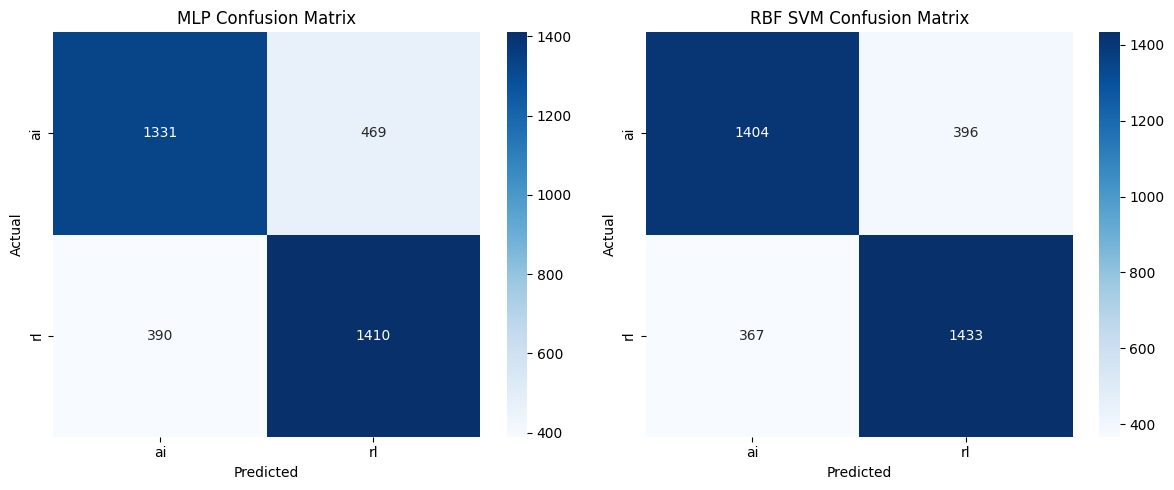


MLP Confusion Matrix (normalized):


,Predicted: ai,Predicted: rl
Actual: ai,0.7394,0.2606
Actual: rl,0.2167,0.7833



RBF SVM Confusion Matrix (normalized):


,Predicted: ai,Predicted: rl
Actual: ai,0.7800,0.2200
Actual: rl,0.2039,0.7961


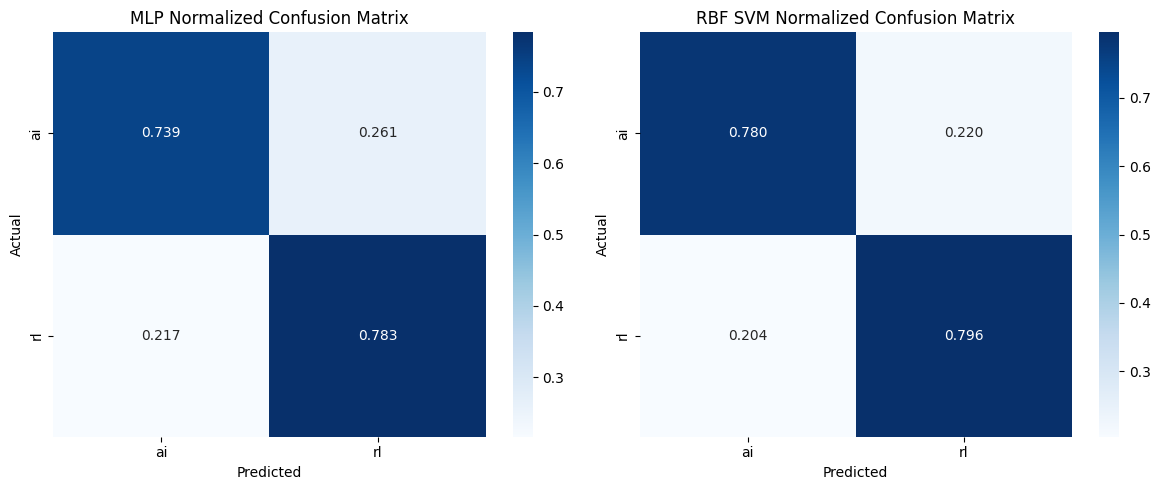

In [ ]:
# ============================================================
# Step 7: Generate and Display Confusion Matrices
# ============================================================

print("Generating confusion matrices...\n")

# ------------------------------------------------------------
# Define class order for confusion matrices
# ------------------------------------------------------------
class_names = [AI_LABEL, REAL_LABEL]
class_order_encoded = label_encoder.transform(class_names)

# ------------------------------------------------------------
# Compute confusion matrices using fixed class order
# ------------------------------------------------------------
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=class_order_encoded)
cm_rbf = confusion_matrix(y_test, y_pred_rbf, labels=class_order_encoded)

print("Confusion matrices computed successfully.")

# ------------------------------------------------------------
# Create raw confusion matrix tables
# ------------------------------------------------------------
cm_mlp_df = pd.DataFrame(
    cm_mlp,
    index=[f"Actual: {label}" for label in class_names],
    columns=[f"Predicted: {label}" for label in class_names]
)

cm_rbf_df = pd.DataFrame(
    cm_rbf,
    index=[f"Actual: {label}" for label in class_names],
    columns=[f"Predicted: {label}" for label in class_names]
)

# ------------------------------------------------------------
# Compute normalized confusion matrices (row-wise)
# ------------------------------------------------------------
cm_mlp_normalized = cm_mlp.astype(float) / cm_mlp.sum(axis=1, keepdims=True)
cm_rbf_normalized = cm_rbf.astype(float) / cm_rbf.sum(axis=1, keepdims=True)

# ------------------------------------------------------------
# Create normalized confusion matrix tables
# ------------------------------------------------------------
cm_mlp_norm_df = pd.DataFrame(
    cm_mlp_normalized,
    index=[f"Actual: {label}" for label in class_names],
    columns=[f"Predicted: {label}" for label in class_names]
)

cm_rbf_norm_df = pd.DataFrame(
    cm_rbf_normalized,
    index=[f"Actual: {label}" for label in class_names],
    columns=[f"Predicted: {label}" for label in class_names]
)

# ------------------------------------------------------------
# Optional detailed display and visualizations
# ------------------------------------------------------------
if VERBOSE:
    print("\nMLP Confusion Matrix (counts):")
    display(cm_mlp_df)

    print("\nRBF SVM Confusion Matrix (counts):")
    display(cm_rbf_df)

    # ------------------------------------------------------------
    # Plot side-by-side confusion matrices (counts)
    # ------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(
        cm_mlp,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[0]
    )
    axes[0].set_title("MLP Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    sns.heatmap(
        cm_rbf,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[1]
    )
    axes[1].set_title("RBF SVM Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

    print("\nMLP Confusion Matrix (normalized):")
    display(cm_mlp_norm_df.round(4))

    print("\nRBF SVM Confusion Matrix (normalized):")
    display(cm_rbf_norm_df.round(4))

    # ------------------------------------------------------------
    # Plot side-by-side normalized confusion matrices
    # ------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(
        cm_mlp_normalized,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[0]
    )
    axes[0].set_title("MLP Normalized Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    sns.heatmap(
        cm_rbf_normalized,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[1]
    )
    axes[1].set_title("RBF SVM Normalized Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()



### 🔷 Step 8 — Generate and Display ROC Curves

- Create binary test target with AI as the positive class  
- Compute ROC curve points for MLP and RBF SVM models  
- Report number of ROC points generated for each model  
- Plot ROC curves for side-by-side model comparison  
- Include random-classifier reference line  
- Display AUC values in ROC curve legend  
- Optionally preview first few ROC points when `VERBOSE=True`  

---

Generating ROC curves...

ROC curves computed successfully.
Number of MLP ROC points: 1184
Number of RBF SVM ROC points: 1046

ROC curve figure saved to: /content/dip-ai-image-detection/metadata/results/roc_curve_comparison.png


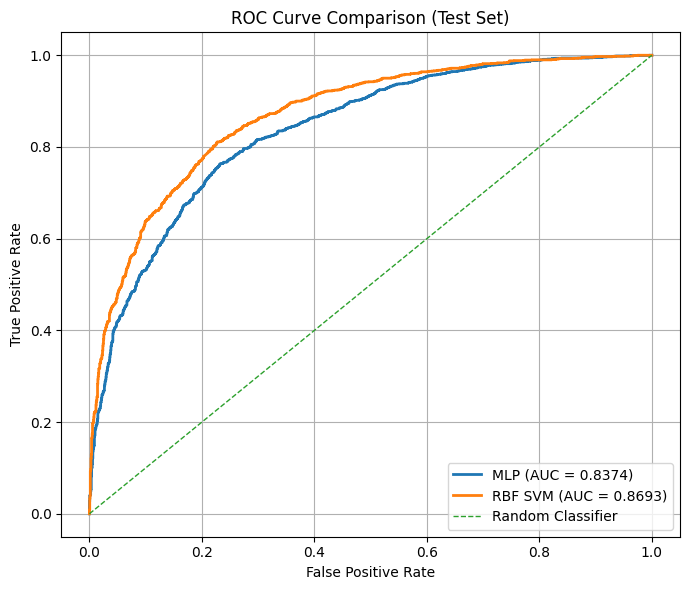

In [ ]:
# ============================================================
# Step 8: Generate, Save, and Display ROC Curves
# ============================================================

print("Generating ROC curves...\n")

# ------------------------------------------------------------
# Create binary target with AI as positive class = 1
# ------------------------------------------------------------
y_test_ai_positive = (df_test["class_label"] == AI_LABEL).astype(int).to_numpy()

# ------------------------------------------------------------
# Compute ROC curve points for both models
# ------------------------------------------------------------
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test_ai_positive, y_score_mlp)
fpr_rbf, tpr_rbf, thresholds_rbf = roc_curve(y_test_ai_positive, y_score_rbf)

print("ROC curves computed successfully.")

# ------------------------------------------------------------
# Optional detailed ROC output and visualization
# ------------------------------------------------------------
if VERBOSE:

    print(f"Number of MLP ROC points: {len(fpr_mlp)}")
    print(f"Number of RBF SVM ROC points: {len(fpr_rbf)}")

    # ------------------------------------------------------------
    # Plot ROC curves for model comparison
    # ------------------------------------------------------------
    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr_mlp,
        tpr_mlp,
        linewidth=2,
        label=f"MLP (AUC = {roc_auc_mlp:.4f})"
    )

    plt.plot(
        fpr_rbf,
        tpr_rbf,
        linewidth=2,
        label=f"RBF SVM (AUC = {roc_auc_rbf:.4f})"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Random Classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison (Test Set)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()

    # ------------------------------------------------------------
    # Save ROC curve figure as PNG
    # ------------------------------------------------------------
    roc_output_path = f"{RESULTS_METADATA_DIR}/roc_curve_comparison.png"

    plt.savefig(
        roc_output_path,
        dpi=300,
        bbox_inches="tight"
    )

print(f"\nROC curve figure saved to: {roc_output_path}")



### 🔷 Step 9 — Summarize Final Test Results in Tabular Form

- Create final results table for MLP and RBF SVM models  
- Include model filenames and final test-set metrics  
- Sort final results by ROC-AUC performance  
- Create report-friendly comparison table across key metrics  
- Display final test-results summary when `VERBOSE=True`  
- Display final comparison summary when `VERBOSE=True`  

---

In [ ]:
# ============================================================
# Step 9: Summarize Final Test Results in Tabular Form
# ============================================================

print("Building final test-results summary tables...\n")

# ------------------------------------------------------------
# Create final results summary table
# ------------------------------------------------------------
df_final_results = pd.DataFrame([
    {
        "model": "MLP",
        "model_file": "final_mlp_model.pkl",
        "accuracy": accuracy_mlp,
        "precision": precision_mlp,
        "recall": recall_mlp,
        "f1_score": f1_mlp,
        "roc_auc": roc_auc_mlp
    },
    {
        "model": "RBF SVM",
        "model_file": "final_rbf_svm_model.pkl",
        "accuracy": accuracy_rbf,
        "precision": precision_rbf,
        "recall": recall_rbf,
        "f1_score": f1_rbf,
        "roc_auc": roc_auc_rbf
    }
])

# ------------------------------------------------------------
# Sort final results by ROC-AUC performance
# ------------------------------------------------------------
df_final_results = df_final_results.sort_values(
    by="roc_auc",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Create report-friendly comparison summary
# ------------------------------------------------------------
df_final_comparison = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "MLP": [
        accuracy_mlp,
        precision_mlp,
        recall_mlp,
        f1_mlp,
        roc_auc_mlp
    ],
    "RBF SVM": [
        accuracy_rbf,
        precision_rbf,
        recall_rbf,
        f1_rbf,
        roc_auc_rbf
    ]
})

print("Final test-results summary tables created.")

# ------------------------------------------------------------
# Optional display of final summary tables
# ------------------------------------------------------------
if VERBOSE:
    print("\nFinal test-results summary table:\n")
    display(df_final_results.round(4))

    print("\nFinal comparison summary:\n")
    display(df_final_comparison.round(4))



Building final test-results summary tables...

Final test-results summary tables created.

Final test-results summary table:



,model,model_file,accuracy,precision,recall,f1_score,roc_auc
0,RBF SVM,final_rbf_svm_model.pkl,0.7881,0.7928,0.7800,0.7863,0.8693
1,MLP,final_mlp_model.pkl,0.7614,0.7734,0.7394,0.7560,0.8374



Final comparison summary:



,metric,MLP,RBF SVM
0,Accuracy,0.7614,0.7881
1,Precision,0.7734,0.7928
2,Recall,0.7394,0.7800
3,F1-score,0.7560,0.7863
4,ROC-AUC,0.8374,0.8693


### 🔷 Step 10 — Save Final Evaluation Outputs

- Save final test-results summary table to CSV  
- Save final metrics dictionary to JSON format  
- Save confusion matrices for MLP and RBF SVM models  
- Save ROC curve point data for both models  
- Save final comparison summary table  
- Optionally display saved file paths when `VERBOSE=True`  
- Confirm successful completion of all output saves  

---

In [ ]:
# ============================================================
# Step 10: Save Final Evaluation Outputs
# ============================================================

print("Saving final evaluation outputs...\n")

# ------------------------------------------------------------
# Save final metric summary table to CSV
# ------------------------------------------------------------
df_final_results.to_csv(FINAL_RESULTS_CSV_PATH, index=False)

# ------------------------------------------------------------
# Save final metrics dictionary as JSON
# ------------------------------------------------------------
final_metrics = {
    "MLP": final_metrics_mlp,
    "RBF_SVM": final_metrics_rbf
}

with open(FINAL_RESULTS_JSON_PATH, "w") as f:
    json.dump(final_metrics, f, indent=4)

# ------------------------------------------------------------
# Save confusion matrices (raw counts)
# ------------------------------------------------------------
cm_mlp_df.to_csv(CONFUSION_MATRIX_MLP_PATH)
cm_rbf_df.to_csv(CONFUSION_MATRIX_RBF_PATH)

# ------------------------------------------------------------
# Save ROC curve points for both models
# ------------------------------------------------------------
df_roc_mlp = pd.DataFrame({
    "threshold": thresholds_mlp,
    "fpr": fpr_mlp,
    "tpr": tpr_mlp
})

df_roc_rbf = pd.DataFrame({
    "threshold": thresholds_rbf,
    "fpr": fpr_rbf,
    "tpr": tpr_rbf
})

df_roc_mlp.to_csv(ROC_POINTS_MLP_PATH, index=False)
df_roc_rbf.to_csv(ROC_POINTS_RBF_PATH, index=False)

# ------------------------------------------------------------
# Save final comparison summary table
# ------------------------------------------------------------
df_final_comparison.to_csv(FINAL_COMPARISON_PATH, index=False)

# ------------------------------------------------------------
# Optional detailed output of saved file paths
# ------------------------------------------------------------
if VERBOSE:
    print(f"Saved final results CSV:            {FINAL_RESULTS_CSV_PATH}")
    print(f"Saved final results JSON:           {FINAL_RESULTS_JSON_PATH}")
    print(f"Saved MLP confusion matrix CSV:     {CONFUSION_MATRIX_MLP_PATH}")
    print(f"Saved RBF SVM confusion matrix CSV: {CONFUSION_MATRIX_RBF_PATH}")
    print(f"Saved MLP ROC curve points CSV:     {ROC_POINTS_MLP_PATH}")
    print(f"Saved RBF ROC curve points CSV:     {ROC_POINTS_RBF_PATH}")
    print(f"Saved comparison summary CSV:       {FINAL_COMPARISON_PATH}")

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------
print("\nAll final evaluation outputs saved successfully.")



Saving final evaluation outputs...

Saved final results CSV:            /content/dip-ai-image-detection/metadata/results/final_test_results.csv
Saved final results JSON:           /content/dip-ai-image-detection/metadata/results/final_test_results.json
Saved MLP confusion matrix CSV:     /content/dip-ai-image-detection/metadata/results/final_confusion_matrix_mlp.csv
Saved RBF SVM confusion matrix CSV: /content/dip-ai-image-detection/metadata/results/final_confusion_matrix_rbf_svm.csv
Saved MLP ROC curve points CSV:     /content/dip-ai-image-detection/metadata/results/final_roc_points_mlp.csv
Saved RBF ROC curve points CSV:     /content/dip-ai-image-detection/metadata/results/final_roc_points_rbf_svm.csv
Saved comparison summary CSV:       /content/dip-ai-image-detection/metadata/results/final_comparison_summary.csv

All final evaluation outputs saved successfully.
